Dataset Loaded: (20, 5)

Average Cost: 417.9157177999999
Average Defect: 6.2234336608
High-risk vendors: 3


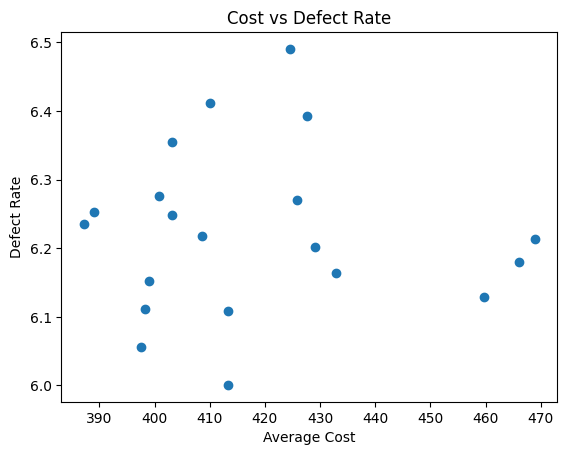

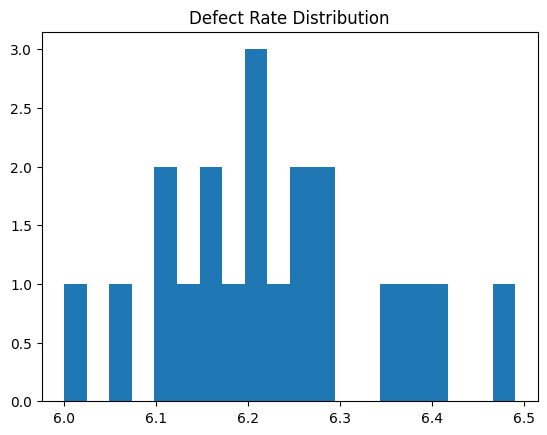


Day 11 Analysis Completed Successfully


In [2]:
# ==========================================================
# HONEYRICH LOGISTICS ANALYTICS
# Day 11 - Supplier Performance Analysis (Corrected)
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

INPUT_FILE = PROJECT_ROOT / "03_processed_data/vendor_performance.csv"

df = pd.read_csv(INPUT_FILE)

print("Dataset Loaded:", df.shape)

# ----------------------------------------------------------
# 1. BASIC STATISTICS
# ----------------------------------------------------------

print("\nAverage Cost:", df["avg_cost"].mean())
print("Average Defect:", df["avg_defect"].mean())

# ----------------------------------------------------------
# 2. HIGH-RISK SUPPLIERS
# High cost + high defect
# ----------------------------------------------------------

high_risk = df[
    (df["avg_cost"] > df["avg_cost"].mean()) &
    (df["avg_defect"] > df["avg_defect"].mean())
]

high_risk.to_csv(
    PROJECT_ROOT / "03_processed_data/high_risk_vendors.csv",
    index=False
)

print("High-risk vendors:", len(high_risk))

# ----------------------------------------------------------
# 3. TOP PERFORMERS
# Low cost + low defect
# ----------------------------------------------------------

top_performers = df[
    (df["avg_defect"] < df["avg_defect"].mean()) &
    (df["avg_cost"] < df["avg_cost"].mean())
]

top_performers.to_csv(
    PROJECT_ROOT / "03_processed_data/top_performing_vendors.csv",
    index=False
)

# ----------------------------------------------------------
# 4. COST INEFFICIENT SUPPLIERS
# High cost suppliers
# ----------------------------------------------------------

cost_inefficient = df[
    (df["avg_cost"] > df["avg_cost"].mean())
]

cost_inefficient.to_csv(
    PROJECT_ROOT / "03_processed_data/cost_inefficient_vendors.csv",
    index=False
)

# ----------------------------------------------------------
# 5. COST vs DEFECT VISUALIZATION
# ----------------------------------------------------------

plt.figure()

plt.scatter(
    df["avg_cost"],
    df["avg_defect"]
)

plt.xlabel("Average Cost")
plt.ylabel("Defect Rate")
plt.title("Cost vs Defect Rate")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/cost_vs_defect.png"
)
plt.show()
plt.close()

# ----------------------------------------------------------
# 6. DEFECT DISTRIBUTION
# ----------------------------------------------------------

plt.figure()

plt.hist(df["avg_defect"], bins=20)

plt.title("Defect Rate Distribution")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/defect_distribution.png"
)
plt.show()
plt.close()

print("\nDay 11 Analysis Completed Successfully")